# XGBoost for Brain Tumour MRI Classification (No PCA)
## Step 1 — Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

## Step 2 — Configuration

In [2]:
IMG_SIZE    = 128
NUM_CLASSES = 4

train_path = '/home/vineet/Downloads/XGBoost/brain-mri/Training'
test_path  = '/home/vineet/Downloads/XGBoost/brain-mri/Testing'

## Step 3 — Data Loading Function

In [3]:
def load_data(path):
    X = []
    y = []

    classes = os.listdir(path)

    for label in classes:
        folder = os.path.join(path, label)

        if not os.path.isdir(folder):
            continue

        print(f"Loading class: {label}")

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            # Resize image
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalise pixel values
            img = img / 255.0

            # Flatten to 1-D feature vector
            img = img.flatten()

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

## Step 4 — Load Data

In [4]:
X_train, y_train = load_data(train_path)
X_test,  y_test  = load_data(test_path)

print("Training data shape:", X_train.shape)
print("Testing data shape: ", X_test.shape)

Loading class: meningioma_tumor
Loading class: no_tumor
Loading class: pituitary_tumor
Loading class: glioma_tumor
Loading class: meningioma_tumor
Loading class: no_tumor
Loading class: pituitary_tumor
Loading class: glioma_tumor
Training data shape: (946, 49152)
Testing data shape:  (394, 49152)


## Step 5 — Label Encoding

In [5]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


## Step 6 — Train Model

In [6]:
model = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    num_class=NUM_CLASSES,
    max_depth=4,
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_encoded)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


## Step 7 — Evaluation Metrics

In [7]:
y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall    = recall_score(y_test_encoded, y_pred, average='weighted')
f1        = f1_score(y_test_encoded, y_pred, average='weighted')

print("=========== TEST METRICS ===========")
print(f"Accuracy : {accuracy  * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall    * 100:.2f}%")
print(f"F1 Score : {f1        * 100:.2f}%")

print("\n=========== CLASSIFICATION REPORT ===========")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

=========== TEST METRICS ===========
Accuracy : 52.79%
Precision: 61.88%
Recall   : 52.79%
F1 Score : 49.46%

=========== CLASSIFICATION REPORT ===========
                  precision    recall  f1-score   support

    glioma_tumor       0.78      0.14      0.24       100
meningioma_tumor       0.58      0.50      0.54       115
        no_tumor       0.42      0.87      0.57       105
 pituitary_tumor       0.74      0.62      0.68        74

        accuracy                           0.53       394
       macro avg       0.63      0.53      0.50       394
    weighted avg       0.62      0.53      0.49       394



## Step 8 — Accuracy vs Training Data Percentage

In [8]:
percentages = [0.2, 0.4, 0.6, 0.8]
xgb_acc = []

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        X_train,
        y_train_encoded,
        train_size=p,
        stratify=y_train_encoded,
        random_state=42
    )

    m = XGBClassifier(
        objective='multi:softmax',
        num_class=NUM_CLASSES,
        eval_metric='mlogloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )
    m.fit(X_subset, y_subset)

    acc = accuracy_score(y_test_encoded, m.predict(X_test))
    xgb_acc.append(acc * 100)

    print(f"{int(p * 100)}% training data  →  Accuracy = {acc * 100:.2f}%")

print("\nAccuracy list:", xgb_acc)

20% training data  →  Accuracy = 47.46%
40% training data  →  Accuracy = 43.65%
60% training data  →  Accuracy = 51.27%
80% training data  →  Accuracy = 50.76%

Accuracy list: [47.46192893401015, 43.65482233502538, 51.26903553299492, 50.76142131979695]


## Step 9 — Visualisation: Confusion Matrix

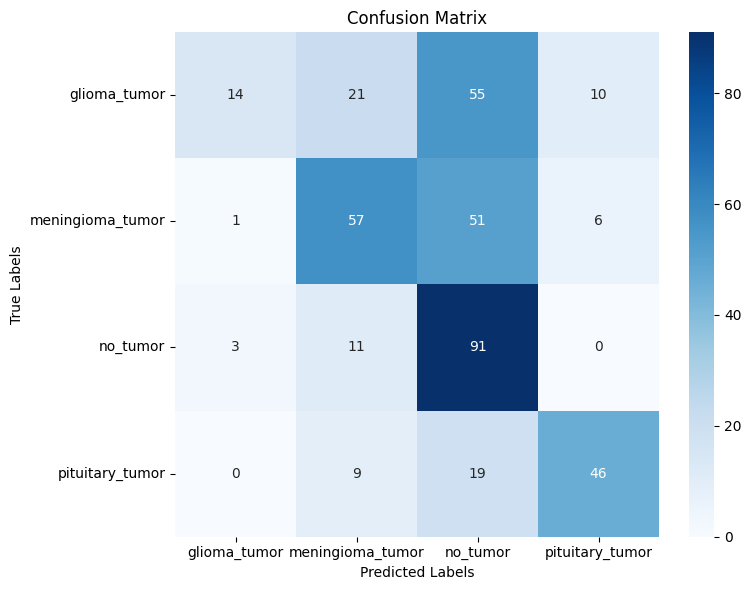

In [9]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 10 — Visualisation: Training vs Validation Loss per Data Percentage

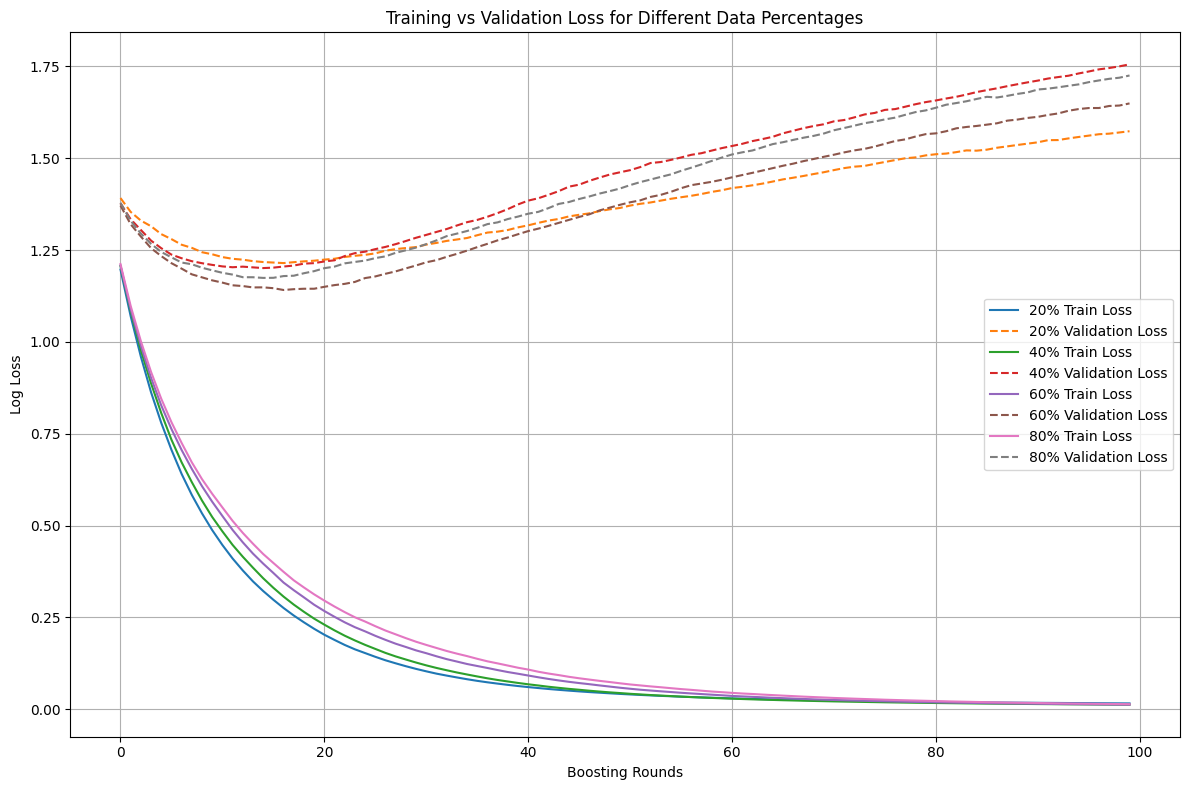

In [10]:
plt.figure(figsize=(12, 8))

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        X_train,
        y_train_encoded,
        train_size=p,
        stratify=y_train_encoded,
        random_state=42
    )

    m = XGBClassifier(
        objective='multi:softmax',
        num_class=NUM_CLASSES,
        eval_metric='mlogloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )

    eval_set = [
        (X_subset, y_subset),
        (X_test,   y_test_encoded)
    ]

    m.fit(X_subset, y_subset, eval_set=eval_set, verbose=False)

    results    = m.evals_result()
    train_loss = results['validation_0']['mlogloss']
    val_loss   = results['validation_1']['mlogloss']

    plt.plot(train_loss,               label=f'{int(p * 100)}% Train Loss')
    plt.plot(val_loss, linestyle='--', label=f'{int(p * 100)}% Validation Loss')

plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different Data Percentages')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()